# Chapter 8 — Directed Graphical Models

This notebook accompanies **Chapter 8** of *Inference in Statistical Modelling and Machine Learning*.

## Key ideas

A **directed acyclic graph (DAG)** is a diagram of nodes (random variables) connected by arrows (direct dependences).  Every DAG corresponds to a factorisation of the joint density into a product of conditional densities — one factor per node:

$$f_{X_1,\ldots,X_n}(x_1,\ldots,x_n) = \prod_{k=1}^n f_{X_k \mid \mathbf{PA}_k}(x_k \mid \mathbf{pa}_k),$$

where $\mathbf{PA}_k$ is the set of *parents* of node $X_k$.

The structure of the graph encodes **conditional independence** relationships.  There are three fundamental three-node patterns, and they behave very differently — especially the *collider*, which produces a surprising result.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

rng = np.random.default_rng(0)

---
## Drawing DAGs

We'll build a small helper to draw DAGs — nodes as labelled circles and edges as arrows.

In [24]:
def draw_dag(ax, nodes, edges, title=''):
    """Draw a DAG on ax. nodes: dict {name: (x,y)}. edges: list of (from, to)."""
    r = 0.07
    for name, (x, y) in nodes.items():
        circle = plt.Circle((x, y), r, color='white', ec='black', linewidth=1.5, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, name, ha='center', va='center', fontsize=11, zorder=4)

    for src, dst in edges:
        x0, y0 = nodes[src]
        x1, y1 = nodes[dst]
        dx, dy = x1 - x0, y1 - y0
        length = np.hypot(dx, dy)
        # shorten to circle boundary
        sx = x0 + r * dx / length
        sy = y0 + r * dy / length
        ex = x1 - r * dx / length
        ey = y1 - r * dy / length
        ax.annotate('', xy=(ex, ey), xytext=(sx, sy),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=11)

---
## The three fundamental structures

> **Book link — §8.2.**  Every three-node path in a DAG is either a pipe, a fork, or a collider.  These three patterns have completely different implications for conditional independence.

| Structure | DAG | Marginal | Conditional on $Y$ |
|-----------|-----|----------|--------------------|
| **Pipe** | $X \to Y \to Z$ | $X$ and $Z$ dependent | $X \perp\!\!\!\perp Z \mid Y$ |
| **Fork** | $X \leftarrow Y \to Z$ | $X$ and $Z$ dependent | $X \perp\!\!\!\perp Z \mid Y$ |
| **Collider** | $X \to Y \leftarrow Z$ | $X \perp\!\!\!\perp Z$ | $X$ and $Z$ **dependent** given $Y$ |

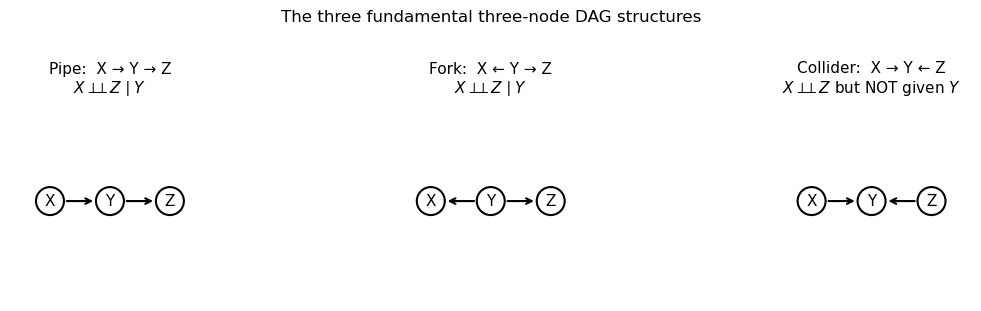

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# Pipe: X → Y → Z
draw_dag(axes[0],
         nodes={'X': (0.2, 0.5), 'Y': (0.5, 0.5), 'Z': (0.8, 0.5)},
         edges=[('X', 'Y'), ('Y', 'Z')],
         title='Pipe:  X → Y → Z\n$X \\perp\\!\\!\\!\\perp Z \\mid Y$')

# Fork: X ← Y → Z
draw_dag(axes[1],
         nodes={'X': (0.2, 0.5), 'Y': (0.5, 0.5), 'Z': (0.8, 0.5)},
         edges=[('Y', 'X'), ('Y', 'Z')],
         title='Fork:  X ← Y → Z\n$X \\perp\\!\\!\\!\\perp Z \\mid Y$')

# Collider: X → Y ← Z
draw_dag(axes[2],
         nodes={'X': (0.2, 0.5), 'Y': (0.5, 0.5), 'Z': (0.8, 0.5)},
         edges=[('X', 'Y'), ('Z', 'Y')],
         title='Collider:  X → Y ← Z\n$X \\perp\\!\\!\\!\\perp Z$ but NOT given $Y$')

plt.suptitle('The three fundamental three-node DAG structures', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

In the pipe and the fork, conditioning on the middle node $Y$ **blocks** the path between $X$ and $Z$, making them independent.  In the collider it is the opposite: $X$ and $Z$ are marginally independent, but conditioning on $Y$ **opens** the path and introduces dependence.

---
## The collider surprise: simulation

The collider is the counterintuitive one.  Let's verify it with a simulation.

> **Book link — §8.2, collider example.**  The book uses the example: a musician's sales revenue $Y$ is the sum of their talent $X$, beauty $Z$, and noise.  Talent and beauty are independently distributed in the population.  But *given a fixed revenue*, more beautiful artists tend to be less talented — the two become negatively correlated.

In [26]:
n = 2000
X = rng.normal(0, 1, n)          # talent: independent
Z = rng.normal(0, 1, n)          # beauty: independent
Y = X + Z + rng.normal(0, 0.5, n)  # revenue = talent + beauty + noise

print("Marginal correlation between talent and beauty:")
print(f"  corr(X, Z) = {np.corrcoef(X, Z)[0,1]:.3f}   ← should be near 0")
print()

# Condition on Y ≈ y0 by taking a narrow slice
y0 = 1.5
tol = 0.4
mask = np.abs(Y - y0) < tol
print(f"Conditional correlation given Y ≈ {y0} (±{tol}):")
print(f"  corr(X, Z | Y ≈ {y0}) = {np.corrcoef(X[mask], Z[mask])[0,1]:.3f}   ← should be strongly negative")
print(f"  (based on {mask.sum()} points in the slice)")

Marginal correlation between talent and beauty:
  corr(X, Z) = -0.017   ← should be near 0

Conditional correlation given Y ≈ 1.5 (±0.4):
  corr(X, Z | Y ≈ 1.5) = -0.761   ← should be strongly negative
  (based on 270 points in the slice)


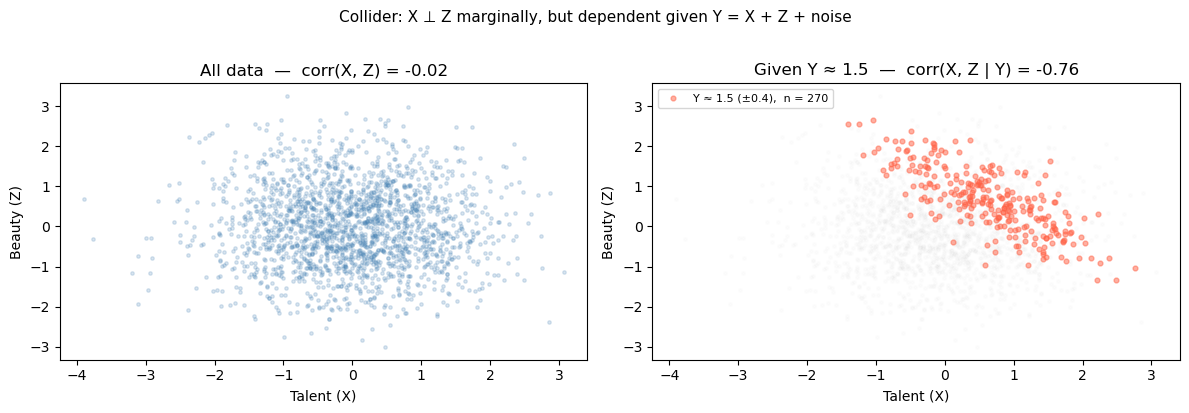

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: all data — X and Z are uncorrelated
axes[0].scatter(X, Z, s=6, alpha=0.2, color='steelblue')
axes[0].set_xlabel('Talent (X)')
axes[0].set_ylabel('Beauty (Z)')
axes[0].set_title(f'All data  —  corr(X, Z) = {np.corrcoef(X, Z)[0,1]:.2f}')

# Right: conditioned on Y ≈ 1.5 — X and Z are negatively correlated
axes[1].scatter(X[~mask], Z[~mask], s=6, alpha=0.05, color='lightgrey')
axes[1].scatter(X[mask],  Z[mask],  s=12, alpha=0.5,  color='tomato',
                label=f'Y ≈ {y0} (±{tol}),  n = {mask.sum()}')
rho_cond = np.corrcoef(X[mask], Z[mask])[0,1]
axes[1].set_xlabel('Talent (X)')
axes[1].set_ylabel('Beauty (Z)')
axes[1].set_title(f'Given Y ≈ {y0}  —  corr(X, Z | Y) = {rho_cond:.2f}')
axes[1].legend(fontsize=8)

plt.suptitle('Collider: X ⊥ Z marginally, but dependent given Y = X + Z + noise',
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

Fixing revenue to a particular level forces a trade-off: if this artist earns that much despite low talent, they must compensate with beauty — and vice versa.  The collider node $Y$ has introduced a spurious negative correlation between two genuinely independent variables.

This is not just a curiosity: it is a common source of **selection bias** in observational studies.

---
## Factorisation and the DAG for a regression model

A DAG isn't just a picture — it immediately tells you the joint density.  The rule is: multiply one conditional density per node, conditioning only on that node's parents.

> **Book link — §8.1.**  For the DAG $X \to Y \leftarrow Z$ (eq. 8.6) the factorisation is $f_{X,Y,Z} = f_{X|Z} \, f_{Y|Z} \, f_Z$.

The simplest regression model $Y = \beta_0 + \beta_1 X + \varepsilon$ also has a natural DAG (book eq. 9.4 previews this for Chapter 9):

- Parameters **B** and $\Sigma$ are root nodes (no parents).
- The predictor $X$ is observed and has no parents.
- The response $Y$ has parents **B**, $X$, $\Sigma$.

The factorisation is therefore
$$f_{Y,\mathbf{B},\Sigma,X} = f_{Y \mid \mathbf{B},\Sigma,X} \; f_{\mathbf{B}} \; f_{\Sigma} \; f_X.$$

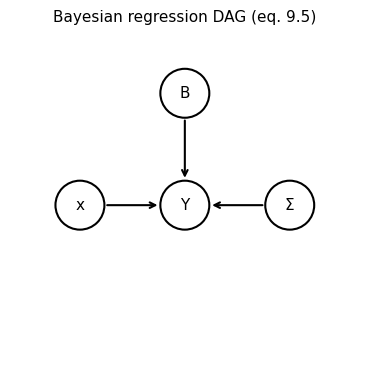

In [28]:
fig, ax = plt.subplots(figsize=(4, 4))
draw_dag(ax,
         nodes={'B': (0.5, 0.82), 'x': (0.2, 0.5), 'Y': (0.5, 0.5), 'Σ': (0.8, 0.5)},
         edges=[('B', 'Y'), ('x', 'Y'), ('Σ', 'Y')],
         title='Bayesian regression DAG (eq. 9.5)')
plt.tight_layout()
plt.show()

---
## Exercises

### Exercise 1 — Read the factorisation

Write down the joint density factorisation that corresponds to the DAG with four nodes:

$$W \to X \to Y \leftarrow Z$$

Draw the DAG using the helper function above.  What conditional independence relationships does it encode?

In [29]:
# Your answer here

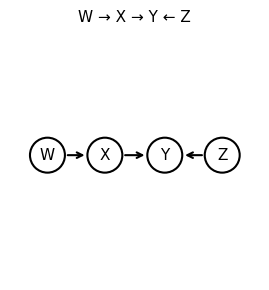

Factorisation:
  f(W, X, Y, Z) = f(W) · f(X|W) · f(Z) · f(Y|X,Z)

Conditional independence relationships:
  W ⊥ Z  (no path between them)
  W ⊥ Y | X  (X blocks the pipe W→X→Y, and the collider X→Y←Z means
               conditioning on X's parent W doesn't open the collider)
  Note: Y is a collider for the path Z→Y←X←W, so W and Z become
        dependent if we condition on Y.


In [30]:
# Solution — DAG
fig, ax = plt.subplots(figsize=(5, 3))
draw_dag(ax,
         nodes={'W': (0.15, 0.5), 'X': (0.38, 0.5), 'Y': (0.62, 0.5), 'Z': (0.85, 0.5)},
         edges=[('W', 'X'), ('X', 'Y'), ('Z', 'Y')],
         title='W → X → Y ← Z')
plt.tight_layout()
plt.show()

print("Factorisation:")
print("  f(W, X, Y, Z) = f(W) · f(X|W) · f(Z) · f(Y|X,Z)")
print()
print("Conditional independence relationships:")
print("  W ⊥ Z  (no path between them)")
print("  W ⊥ Y | X  (X blocks the pipe W→X→Y, and the collider X→Y←Z means")
print("               conditioning on X's parent W doesn't open the collider)")
print("  Note: Y is a collider for the path Z→Y←X←W, so W and Z become")
print("        dependent if we condition on Y.")

### Exercise 2 — Fork vs collider simulation

Simulate the **fork** structure $X \leftarrow Y \to Z$ and verify:

- Marginally, $X$ and $Z$ are correlated (because $Y$ is their common cause).
- Conditioning on $Y$ makes them uncorrelated.

Use: $Y \sim N(0,1)$, $X = Y + \varepsilon_X$, $Z = Y + \varepsilon_Z$ where $\varepsilon_X, \varepsilon_Z \sim N(0, 0.5^2)$.

In [31]:
# Your answer here

Fork:  X ← Y → Z
  corr(X, Z) = 0.802  (marginal — should be positive)
  corr(X, Z | Y ≈ 0.0) = 0.027  (should be near 0)


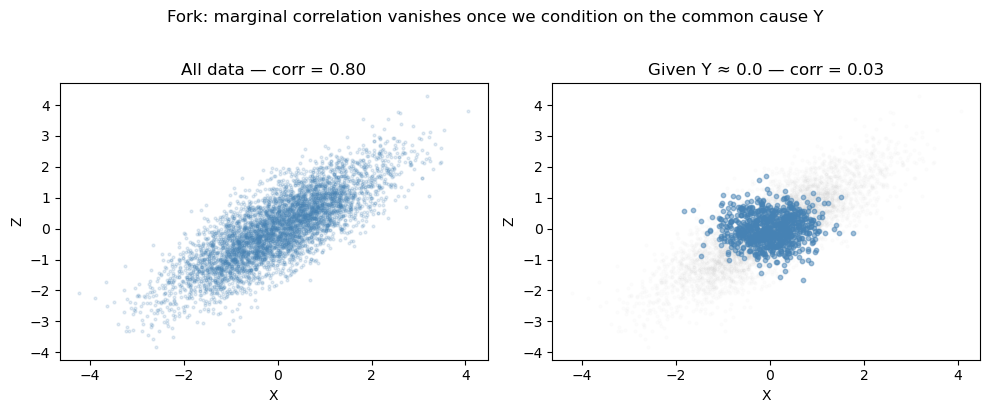

In [32]:
# Solution
n = 5000
Y_fork = rng.normal(0, 1, n)
X_fork = Y_fork + rng.normal(0, 0.5, n)
Z_fork = Y_fork + rng.normal(0, 0.5, n)

print("Fork:  X ← Y → Z")
print(f"  corr(X, Z) = {np.corrcoef(X_fork, Z_fork)[0,1]:.3f}  (marginal — should be positive)")

y0, tol = 0.0, 0.2
mask_fork = np.abs(Y_fork - y0) < tol
print(f"  corr(X, Z | Y ≈ {y0}) = {np.corrcoef(X_fork[mask_fork], Z_fork[mask_fork])[0,1]:.3f}  (should be near 0)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_fork, Z_fork, s=4, alpha=0.15, color='steelblue')
axes[0].set_title(f'All data — corr = {np.corrcoef(X_fork, Z_fork)[0,1]:.2f}')
axes[0].set_xlabel('X');  axes[0].set_ylabel('Z')

r_cond = np.corrcoef(X_fork[mask_fork], Z_fork[mask_fork])[0,1]
axes[1].scatter(X_fork[~mask_fork], Z_fork[~mask_fork], s=4, alpha=0.05, color='lightgrey')
axes[1].scatter(X_fork[mask_fork],  Z_fork[mask_fork],  s=10, alpha=0.5, color='steelblue')
axes[1].set_title(f'Given Y ≈ {y0} — corr = {r_cond:.2f}')
axes[1].set_xlabel('X');  axes[1].set_ylabel('Z')

plt.suptitle('Fork: marginal correlation vanishes once we condition on the common cause Y', y=1.02)
plt.tight_layout()
plt.show()

### Exercise 3 — d-separation by inspection

Consider the DAG from §8.2 (eq. 8.14):

$$V \to X \leftarrow W \leftarrow Y \to Z \leftarrow X$$

(i.e., edges $V \to X$, $W \to X$, $Y \to W$, $Y \to Z$, $X \to Z$).

Draw this DAG.  Then determine by inspection:

(a) Are $Y$ and $V$ d-separated given $\{W, X\}$?
(b) Are $V$ and $W$ d-separated given $\emptyset$ (marginally)?
(c) Are $V$ and $Z$ d-separated given $\emptyset$ (marginally)?
(d) Are $V$ and $W$ d-separated given $\{X\}$?
(e) Are $Y$ and $V$ d-separated given $\{Z\}$?
(f) Are $V$ and $Z$ d-separated given $\{X, W\}$?

Verify each answer by simulating the DAG with Gaussian variables and checking correlations.

In [33]:
# Your answer here

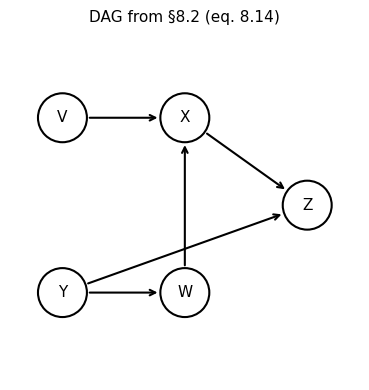

(a) Y ⊥ V | {W, X}?  YES — expect ≈ 0
    partial corr(Y, V | W, X) = -0.000

(b) V ⊥ W marginally?  YES — expect ≈ 0
    corr(V, W) = -0.000

(c) V ⊥ Z marginally?  NO — pipe V→X→Z is active (X ∉ ∅); expect corr ≠ 0
    corr(V, Z) = 0.417

(d) V ⊥ W | {X}?  NO — collider X ∈ C opens V→X←W (Box 8.2c fails); expect corr ≠ 0
    partial corr(V, W | X) = -0.816

(e) Y ⊥ V | {Z}?  NO — collider Z ∈ C opens Y→Z←X←V (Box 8.2c fails); expect corr ≠ 0
    partial corr(Y, V | Z) = -0.694

(f) V ⊥ Z | {X, W}?  YES — path 1 blocked at X (Box 8.2a); path 2 blocked at W (Box 8.2a)
    partial corr(V, Z | X, W) = -0.000


In [35]:
# Solution — DAG figure
fig, ax = plt.subplots(figsize=(5, 4))
draw_dag(ax,
         nodes={'V': (0.15, 0.75), 'X': (0.5, 0.75),
                'W': (0.5, 0.25), 'Y': (0.15, 0.25), 'Z': (0.85, 0.5)},
         edges=[('V', 'X'), ('W', 'X'), ('Y', 'W'), ('Y', 'Z'), ('X', 'Z')],
         title='DAG from §8.2 (eq. 8.14)')
plt.tight_layout()
plt.show()

# Simulate
n = 10**7
V = rng.normal(0, 1, n)
Y = rng.normal(0, 1, n)
W = Y + rng.normal(0, 0.5, n)
X = V + W + rng.normal(0, 0.5, n)
Z = Y + X + rng.normal(0, 0.5, n)

def partial_resid(target, regressors):
    A = np.column_stack([np.ones(n)] + list(regressors))
    return target - A @ np.linalg.lstsq(A, target, rcond=None)[0]

# --- d-separation analysis using Box 8.2 ---
# A path is blocked by C if it contains:
#   (a) a pipe X→Y→Z or X←Y←Z with Y ∈ C, OR
#   (b) a fork X←Y→Z with Y ∈ C, OR
#   (c) a collider X→Y←Z with Y ∉ C and DESC(Y) ∩ C = ∅.
# A and B are d-separated by C if ALL paths between them are blocked.

# (a) Y ⊥ V | {W, X}?  YES
# Path 1  Y→W→X←V :  pipe at W (W ∈ {W,X}) → blocked (Box 8.2a).
# Path 2  Y→Z←X←V :  collider at Z; Z ∉ {W,X} and DESC(Z) = ∅ → blocked (Box 8.2c).
# All paths blocked ⇒ d-separated.
res_Y_WX = partial_resid(Y, [W, X])
res_V_WX = partial_resid(V, [W, X])
print("(a) Y ⊥ V | {W, X}?  YES — expect ≈ 0")
print(f"    partial corr(Y, V | W, X) = {np.corrcoef(res_Y_WX, res_V_WX)[0,1]:.3f}")
print()

# (b) V ⊥ W | ∅?  YES
# Path   V→X←W :  collider at X; X ∉ ∅ and DESC(X) = {Z}, Z ∉ ∅ → blocked (Box 8.2c).
# Only path is blocked ⇒ d-separated.
print("(b) V ⊥ W marginally?  YES — expect ≈ 0")
print(f"    corr(V, W) = {np.corrcoef(V, W)[0,1]:.3f}")
print()

# (c) V ⊥ Z | ∅?  NO
# Path   V→X→Z :  pipe at X; X ∉ ∅ so condition (a) does not apply.
#                  X is not a collider here, so (c) does not apply.
#                  Path is active ⇒ NOT d-separated.
print("(c) V ⊥ Z marginally?  NO — pipe V→X→Z is active (X ∉ ∅); expect corr ≠ 0")
print(f"    corr(V, Z) = {np.corrcoef(V, Z)[0,1]:.3f}")
print()

# (d) V ⊥ W | {X}?  NO
# Path   V→X←W :  collider at X; but X ∈ {X} so condition (c) fails — collider is opened.
#                  Path is active ⇒ NOT d-separated.
# Compare with (b): the same pair that is marginally independent becomes dependent
# once we condition on their common effect X (collider activation, Box 8.2c).
res_V_X = partial_resid(V, [X])
res_W_X = partial_resid(W, [X])
print("(d) V ⊥ W | {X}?  NO — collider X ∈ C opens V→X←W (Box 8.2c fails); expect corr ≠ 0")
print(f"    partial corr(V, W | X) = {np.corrcoef(res_V_X, res_W_X)[0,1]:.3f}")
print()

# (e) Y ⊥ V | {Z}?  NO
# Path  Y→Z←X←V :  collider at Z; Z ∈ {Z} so condition (c) fails — collider is opened.
#                   After Z: X is a non-collider (pipe Z←X←V) and X ∉ {Z}, so (a) does not block.
#                   Path is active ⇒ NOT d-separated.
res_Y_Z = partial_resid(Y, [Z])
res_V_Z = partial_resid(V, [Z])
print("(e) Y ⊥ V | {Z}?  NO — collider Z ∈ C opens Y→Z←X←V (Box 8.2c fails); expect corr ≠ 0")
print(f"    partial corr(Y, V | Z) = {np.corrcoef(res_Y_Z, res_V_Z)[0,1]:.3f}")
print()

# (f) V ⊥ Z | {X, W}?  YES
# Path 1  V→X→Z :    pipe at X; X ∈ {X,W} → blocked (Box 8.2a).
# Path 2  V→X←W←Y→Z : collider at X; X ∈ C so condition (c) fails — X is opened.
#                       But then pipe at W (Y→W→X, i.e. X←W←Y); W ∈ {X,W} → blocked (Box 8.2a).
# All paths blocked ⇒ d-separated.
# Note: conditioning on X alone (part d) opens X but leaves path 2 active through W;
# adding W to C then closes it.
res_V_XW = partial_resid(V, [X, W])
res_Z_XW = partial_resid(Z, [X, W])
print("(f) V ⊥ Z | {X, W}?  YES — path 1 blocked at X (Box 8.2a); path 2 blocked at W (Box 8.2a)")
print(f"    partial corr(V, Z | X, W) = {np.corrcoef(res_V_XW, res_Z_XW)[0,1]:.3f}")